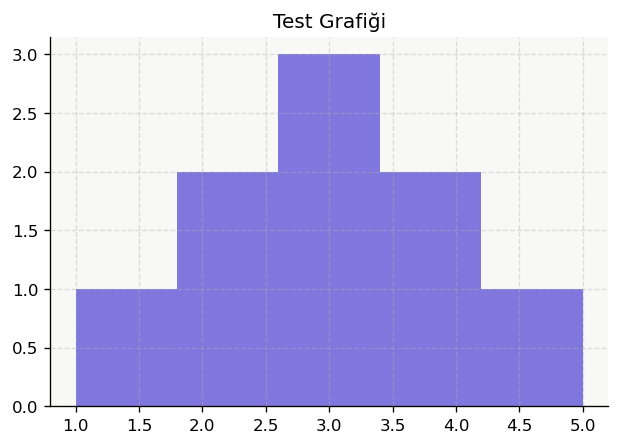

In [44]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(figsize=(6, 4))
ax.hist([1,2,2,3,3,3,4,4,5], bins=5, color='#7F77DD')
ax.set_title('Test Grafiği')
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [4]:
warnings.filterwarnings('ignore')

In [6]:
plt.rcParams.update({
    'figure.dpi' : 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
    })

In [7]:
PALETTE = ['#7F77DD', '#1D9E75', '#185FA5', '#BA7517', '#A32D2D']

print("Kütüphaneler yüklendi!")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")

Kütüphaneler yüklendi!
pandas  : 2.3.3
numpy   : 2.3.5


In [8]:
np.random.seed(42)
N = 1_000_000

In [9]:
print("{N;,} satır üretiliyor...")

{N;,} satır üretiliyor...


In [11]:
customer_ids = np.random.randint(10000, 60000, size=N)

In [13]:
dates = pd.date_range('2024-01-01', '2026-12-31', periods=N)

In [15]:
quantities = np.random.exponential(scale=5, size=N).astype(int) + 1
unit_prices = np.round(np.random.exponential(scale=15, size=N) + 0.99, 2)

In [16]:
countries = np.random.choice(
    ['United Kingdom', 'Germany', 'France', 'Spain', 'Netherlands',
     'Italy', 'Belgium', 'Sweden', 'Australia', 'USA'],
    size=N,
    p=[0.60, 0.10, 0.08, 0.05, 0.04, 0.04, 0.03, 0.02, 0.02, 0.02]
)

In [17]:
df_raw = pd.DataFrame({
    'InvoiceNo':   ['INV' + str(i) for i in np.random.randint(100000, 999999, size=N)],
    'Quantity':    quantities,
    'InvoiceDate': dates,
    'UnitPrice':   unit_prices,
    'CustomerID':  customer_ids.astype(float),
    'Country':     countries,
})

In [18]:
cancel_idx = np.random.choice(N, int(N * 0.02), replace=False)
df_raw.loc[np.random.choice(N, int(N * 0.08), replace=False), 'CustomerID'] = np.nan
df_raw.loc[cancel_idx, 'Quantity']  = -df_raw.loc[cancel_idx, 'Quantity']
df_raw.loc[cancel_idx, 'InvoiceNo'] = 'C' + df_raw.loc[cancel_idx, 'InvoiceNo']
df_raw.loc[np.random.choice(N, int(N * 0.01), replace=False), 'UnitPrice'] = 0.0

In [19]:
print(f"Veri üretildi!")
print(f"\nShape               : {df_raw.shape}")
print(f"Bellek kullanımı    : {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Tarih aralığı       : {df_raw['InvoiceDate'].min().date()} → {df_raw['InvoiceDate'].max().date()}")
print(f"\nİlk 5 satır:")
df_raw.head()

Veri üretildi!

Shape               : (1000000, 6)
Bellek kullanımı    : 143.1 MB
Tarih aralığı       : 2024-01-01 → 2026-12-31

İlk 5 satır:


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV623265,1,2024-01-01 00:00:00.000000000,2.62,25795.0,Spain
1,INV600404,4,2024-01-01 00:01:34.608094608,30.85,NaN,Germany
2,INV172923,6,2024-01-01 00:03:09.216189216,63.21,NaN,United Kingdom
3,INV139191,7,2024-01-01 00:04:43.824283824,6.04,54732.0,Netherlands
4,INV217061,5,2024-01-01 00:06:18.432378432,4.71,21284.0,United Kingdom


In [22]:
df = df_raw.copy()

In [23]:
print("=" * 50)
print("  VERİ KALİTESİ RAPORU")
print("=" * 50)
print(f"  Ham kayıt sayısı     : {len(df):>10,}")

  VERİ KALİTESİ RAPORU
  Ham kayıt sayısı     :  1,000,000


In [24]:
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f"  Eksik CustomerID (-) : {before - len(df):>10,}")

  Eksik CustomerID (-) :     80,000


In [25]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [26]:
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]  # 'C' ile başlayanları çıkar
df = df[df['Quantity'] > 0]                                 # negatif miktarları çıkar
print(f"  İade / iptal     (-) : {before - len(df):>10,}")

  İade / iptal     (-) :     18,388


In [27]:
before = len(df)
df = df[df['UnitPrice'] > 0]
print(f"  Sıfır fiyat      (-) : {before - len(df):>10,}")

  Sıfır fiyat      (-) :      9,012


In [28]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [29]:
Q1 = df['TotalPrice'].quantile(0.01)   # en düşük %1
Q3 = df['TotalPrice'].quantile(0.99)   # en yüksek %1

In [30]:
before = len(df)
df = df[(df['TotalPrice'] >= Q1) & (df['TotalPrice'] <= Q3)]
print(f"  Aykırı değer     (-) : {before - len(df):>10,}")

  Aykırı değer     (-) :     17,762


In [31]:
print("=" * 50)
print(f"  Temiz kayıt sayısı   : {len(df):>10,}")
print(f"  Benzersiz müşteri    : {df['CustomerID'].nunique():>10,}")
print(f"  Benzersiz fatura     : {df['InvoiceNo'].nunique():>10,}")
print(f"  Tarih aralığı        : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"  Kalan veri oranı     : %{len(df)/len(df_raw)*100:.1f}")
print("=" * 50)

  Temiz kayıt sayısı   :    874,838
  Benzersiz müşteri    :     50,000
  Benzersiz fatura     :    559,048
  Tarih aralığı        : 2024-01-01 → 2026-12-31
  Kalan veri oranı     : %87.5


In [32]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"📅 Snapshot tarihi: {snapshot_date.date()}")
print(f"   (Bu tarih 'bugün' kabul ediliyor)\n")

📅 Snapshot tarihi: 2027-01-01
   (Bu tarih 'bugün' kabul ediliyor)



In [33]:
rfm = (
    df.groupby('CustomerID')
      .agg(
          recency  =('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
          frequency=('InvoiceNo',   'nunique'),   # kaç farklı fatura
          monetary =('TotalPrice',  'sum'),        # toplam harcama
      )
      .reset_index()
)

In [34]:
print(f" RFM tablosu oluşturuldu!")
print(f"   Shape: {rfm.shape}  ← 50.000 müşteri, 4 sütun\n")

 RFM tablosu oluşturuldu!
   Shape: (50000, 4)  ← 50.000 müşteri, 4 sütun



In [35]:
print("İlk 5 müşteri:")
print(rfm.head().to_string(index=False))

İlk 5 müşteri:
 CustomerID  recency  frequency  monetary
      10000       73          8    954.49
      10001      125         16   1507.21
      10002       94         17   1571.90
      10003      101         25   2481.86
      10004       61         14    875.43


In [36]:
print(f"\n{'='*45}")
print("  İSTATİSTİKSEL ÖZET")
print(f"{'='*45}")
print(rfm[['recency','frequency','monetary']].describe().round(1).to_string())


  İSTATİSTİKSEL ÖZET
       recency  frequency  monetary
count  50000.0    50000.0   50000.0
mean      62.6       17.5    1406.9
std       61.5        4.2     544.7
min        1.0        3.0      70.9
25%       18.0       15.0    1011.6
50%       44.0       17.0    1349.4
75%       87.0       20.0    1741.5
max      621.0       40.0    4609.0


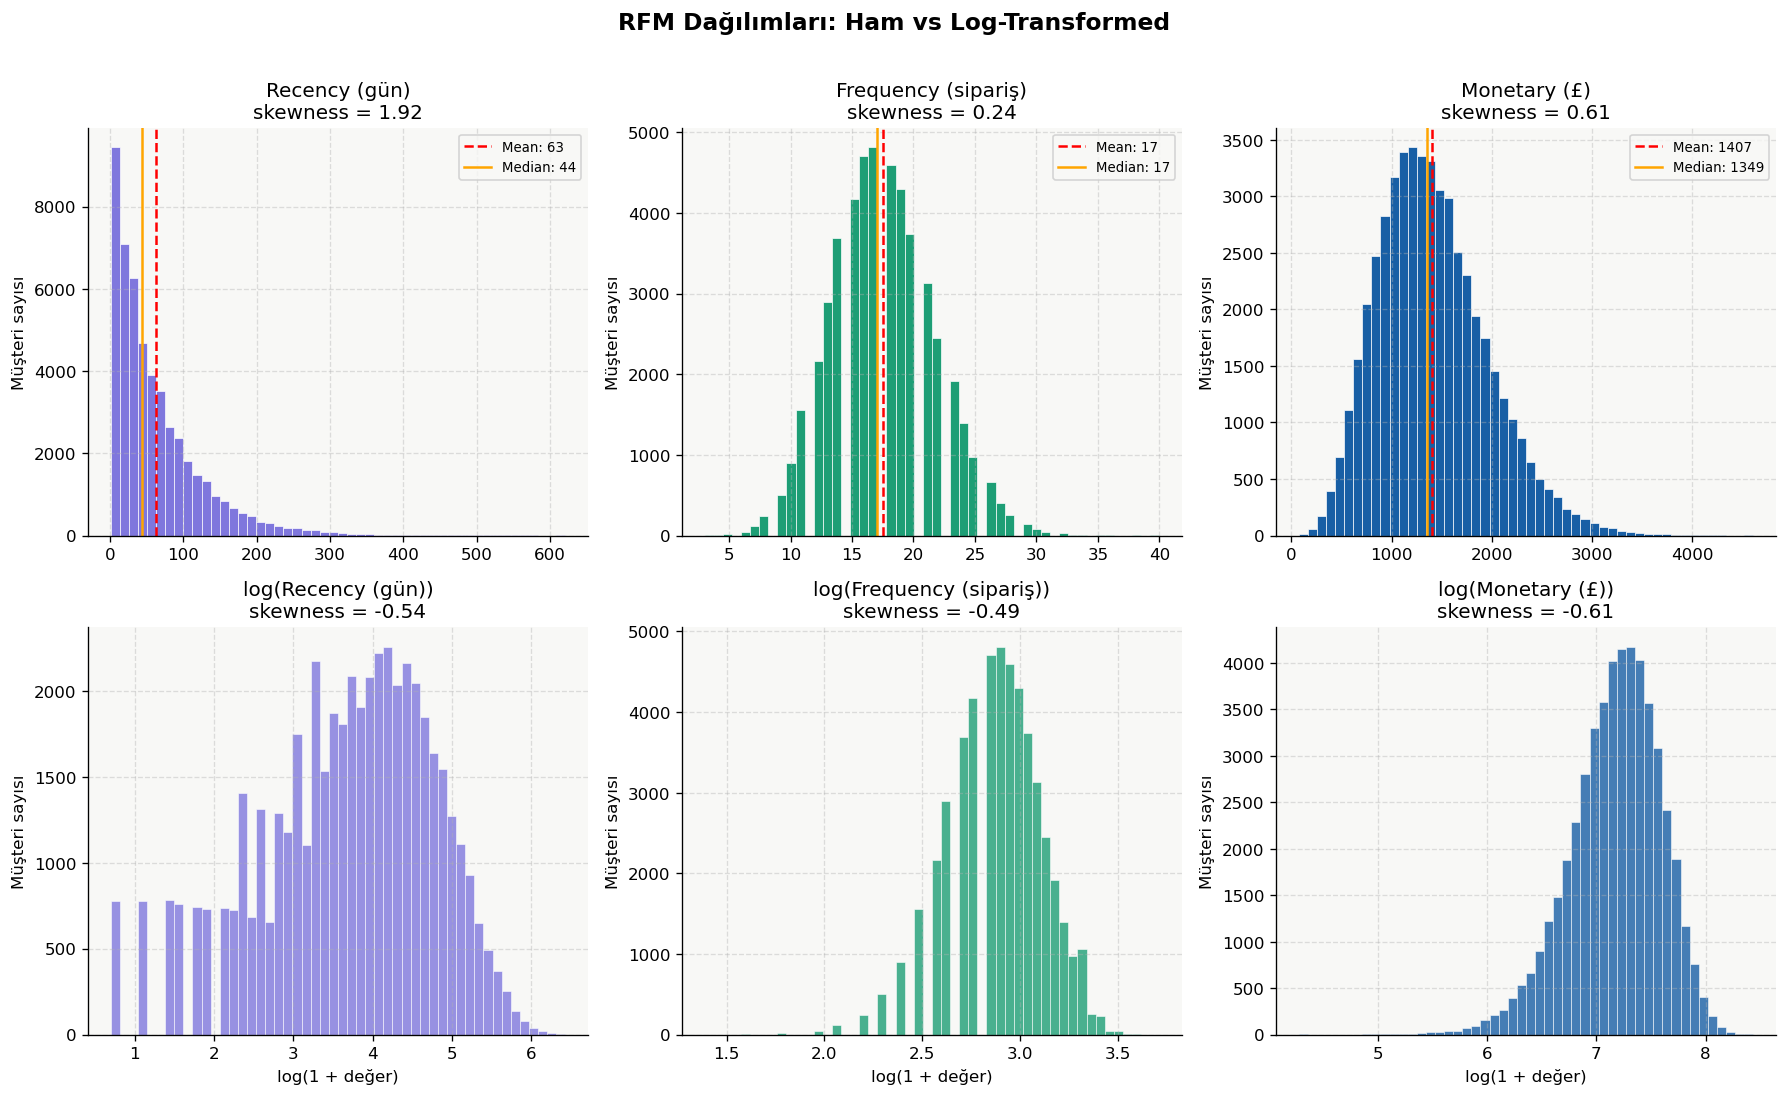


 Yorum rehberi:
  Skewness > +1  → sağa çarpık (sorunlu)
  Skewness < -1  → sola çarpık (sorunlu)
  Skewness ≈ 0   → normal dağılım (ideal)


In [45]:

%matplotlib inline

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('RFM Dağılımları: Ham vs Log-Transformed', 
             fontsize=14, fontweight='bold', y=1.01)

cols   = ['recency', 'frequency', 'monetary']
colors = ['#7F77DD', '#1D9E75', '#185FA5']
titles = ['Recency (gün)', 'Frequency (sipariş)', 'Monetary (£)']


for i, (col, color, title) in enumerate(zip(cols, colors, titles)):
    ax = axes[0, i]
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{title}\nskewness = {rfm[col].skew():.2f}')
    ax.set_ylabel('Müşteri sayısı')
    ax.axvline(rfm[col].mean(),   color='red',    linestyle='--', 
               linewidth=1.5, label=f'Mean: {rfm[col].mean():.0f}')
    ax.axvline(rfm[col].median(), color='orange', linestyle='-',  
               linewidth=1.5, label=f'Median: {rfm[col].median():.0f}')
    ax.legend(fontsize=8)


for i, (col, color, title) in enumerate(zip(cols, colors, titles)):
    ax = axes[1, i]
    log_data = np.log1p(rfm[col])
    ax.hist(log_data, bins=50, color=color, edgecolor='white', 
            linewidth=0.4, alpha=0.8)
    ax.set_title(f'log({title})\nskewness = {log_data.skew():.2f}')
    ax.set_ylabel('Müşteri sayısı')
    ax.set_xlabel('log(1 + değer)')

plt.tight_layout()
plt.show()

print("\n Yorum rehberi:")
print("  Skewness > +1  → sağa çarpık (sorunlu)")
print("  Skewness < -1  → sola çarpık (sorunlu)")
print("  Skewness ≈ 0   → normal dağılım (ideal)")

In [46]:
rfm_log = rfm[['recency', 'frequency', 'monetary']].apply(np.log1p)

print("Log transform sonrası skewness:")
for col in ['recency', 'frequency', 'monetary']:
    before = rfm[col].skew()
    after  = rfm_log[col].skew()
    ok     = "✅" if abs(after) < abs(before) else "➡️"
    print(f"  {ok} {col:<12} {before:+.2f}  →  {after:+.2f}")


scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)


print(f"\nScaled array shape  : {rfm_scaled.shape}")
print(f"Ortalama (≈0 olmalı): {rfm_scaled.mean(axis=0).round(4)}")
print(f"Std     (≈1 olmalı) : {rfm_scaled.std(axis=0).round(4)}")

print("\n✅ Preprocessing tamamlandı!")
print("   rfm_scaled → K-Means'e verilmeye hazır")

Log transform sonrası skewness:
  ✅ recency      +1.92  →  -0.54
  ➡️ frequency    +0.24  →  -0.49
  ✅ monetary     +0.61  →  -0.61

Scaled array shape  : (50000, 3)
Ortalama (≈0 olmalı): [ 0. -0. -0.]
Std     (≈1 olmalı) : [1. 1. 1.]

✅ Preprocessing tamamlandı!
   rfm_scaled → K-Means'e verilmeye hazır


K değerleri hesaplanıyor...
---------------------------------------------
  k=2  |  inertia=    96,334  |  silhouette=0.317
  k=3  |  inertia=    73,932  |  silhouette=0.288
  k=4  |  inertia=    61,325  |  silhouette=0.265
  k=5  |  inertia=    53,575  |  silhouette=0.249
  k=6  |  inertia=    48,792  |  silhouette=0.225
  k=7  |  inertia=    44,338  |  silhouette=0.235
  k=8  |  inertia=    40,884  |  silhouette=0.235
  k=9  |  inertia=    38,249  |  silhouette=0.232
  k=10  |  inertia=    35,820  |  silhouette=0.233
---------------------------------------------
✅ En yüksek silhouette: k=2


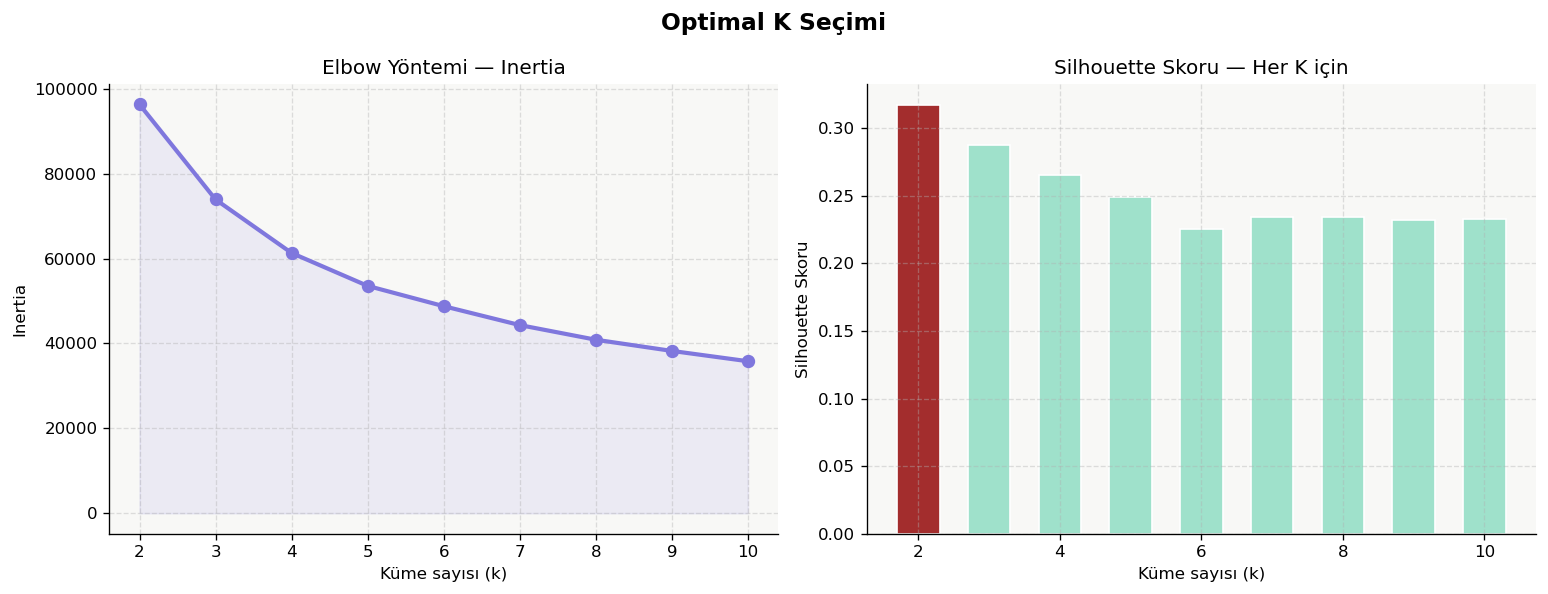

In [47]:
%matplotlib inline

K_RANGE     = range(2, 11)
inertias    = []
silhouettes = []

print("K değerleri hesaplanıyor...")
print("-" * 45)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    
    inertias.append(km.inertia_)
    sil = silhouette_score(rfm_scaled, labels, sample_size=10000)
    silhouettes.append(sil)
    
    print(f"  k={k}  |  inertia={km.inertia_:>10,.0f}  |  silhouette={sil:.3f}")

print("-" * 45)
print(f"✅ En yüksek silhouette: k={silhouettes.index(max(silhouettes))+2}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimal K Seçimi', fontsize=14, fontweight='bold')

# Elbow
ax1.plot(K_RANGE, inertias, 'o-', color='#7F77DD', linewidth=2.5, markersize=7)
ax1.fill_between(K_RANGE, inertias, alpha=0.1, color='#7F77DD')
ax1.set_title('Elbow Yöntemi — Inertia')
ax1.set_xlabel('Küme sayısı (k)')
ax1.set_ylabel('Inertia')

# Silhouette
ax2.bar(K_RANGE, silhouettes,
        color=['#A32D2D' if s == max(silhouettes) else '#9FE1CB' for s in silhouettes],
        edgecolor='white', width=0.6)
ax2.set_title('Silhouette Skoru — Her K için')
ax2.set_xlabel('Küme sayısı (k)')
ax2.set_ylabel('Silhouette Skoru')

plt.tight_layout()
plt.show()

In [49]:
OPTIMAL_K = 5

print(f"⏳ K-Means eğitiliyor (k={OPTIMAL_K})...")

kmeans = KMeans(
    n_clusters = OPTIMAL_K,
    random_state= 42,        
    n_init      = 10,        
    max_iter    = 300        
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


sil = silhouette_score(rfm_scaled, rfm['Cluster'], sample_size=10000)
db  = davies_bouldin_score(rfm_scaled, rfm['Cluster'])

print(f"\n{'='*45}")
print(f"  MODEL DEĞERLENDİRME")
print(f"{'='*45}")
print(f"  Silhouette Skoru     : {sil:.3f}  (yüksek = iyi)")
print(f"  Davies-Bouldin Index : {db:.3f}  (düşük  = iyi)")
print(f"{'='*45}")


print(f"\nKüme dağılımı:")
for cluster, count in rfm['Cluster'].value_counts().sort_index().items():
    bar = '█' * int(count / 500)
    print(f"  Küme {cluster}: {count:>6,} müşteri  {bar}")

print(f"\n✅ Model hazır! rfm['Cluster'] sütunu eklendi.")

⏳ K-Means eğitiliyor (k=5)...

  MODEL DEĞERLENDİRME
  Silhouette Skoru     : 0.250  (yüksek = iyi)
  Davies-Bouldin Index : 1.112  (düşük  = iyi)

Küme dağılımı:
  Küme 0: 14,493 müşteri  ████████████████████████████
  Küme 1:  8,538 müşteri  █████████████████
  Küme 2:  6,567 müşteri  █████████████
  Küme 3: 12,757 müşteri  █████████████████████████
  Küme 4:  7,645 müşteri  ███████████████

✅ Model hazır! rfm['Cluster'] sütunu eklendi.


In [50]:

cluster_summary = (
    rfm.groupby('Cluster')
       .agg(
           müşteri_sayısı =('CustomerID', 'count'),
           ort_recency    =('recency',    'mean'),
           ort_frequency  =('frequency',  'mean'),
           ort_monetary   =('monetary',   'mean'),
       )
       .round(1)
)

print("Küme Özeti (ham RFM ortalamaları):")
print("=" * 60)
print(cluster_summary.to_string())
print("=" * 60)

# ── Otomatik etiketleme ───────────────────────────────────────────────────────
# Skor: düşük recency + yüksek frequency + yüksek monetary = iyi müşteri
cluster_summary['skor'] = (
    cluster_summary['ort_frequency'] +
    cluster_summary['ort_monetary'] / 100 -
    cluster_summary['ort_recency'] / 10
)

# Skora göre sırala ve etiket ata
siralanmis = cluster_summary['skor'].rank(ascending=False).astype(int)

etiket_map = {
    1: 'Champions',
    2: 'Loyal Customers', 
    3: 'At Risk',
    4: 'Promising',
    5: 'Churned'
}

rfm['Segment'] = rfm['Cluster'].map(
    {cluster: etiket_map[rank] for cluster, rank in siralanmis.items()}
)

# ── Sonuç tablosu ─────────────────────────────────────────────────────────────
print("\nSegment Profilleri:")
print("=" * 70)
segment_profil = (
    rfm.groupby('Segment')
       .agg(
           Müşteri  =('CustomerID', 'count'),
           Recency  =('recency',    'mean'),
           Frequency=('frequency',  'mean'),
           Monetary =('monetary',   'mean'),
       )
       .round(1)
)


sira = ['Champions', 'Loyal Customers', 'At Risk', 'Promising', 'Churned']
print(segment_profil.reindex(sira).to_string())
print("=" * 70)

print("\n💡 Okuma rehberi:")
print("  Recency   → DÜŞÜK iyi  (yakın zamanda alışveriş)")
print("  Frequency → YÜKSEK iyi (çok sipariş)")
print("  Monetary  → YÜKSEK iyi (çok harcama)")

Küme Özeti (ham RFM ortalamaları):
         müşteri_sayısı  ort_recency  ort_frequency  ort_monetary
Cluster                                                          
0                 14493         98.4           16.1        1269.4
1                  8538         15.7           15.5        1077.7
2                  6567        104.0           11.8         717.5
3                 12757         63.9           21.3        1897.0
4                  7645          9.5           20.9        1810.0

Segment Profilleri:
                 Müşteri  Recency  Frequency  Monetary
Segment                                               
Champions           7645      9.5       20.9    1810.0
Loyal Customers    12757     63.9       21.3    1897.0
At Risk             8538     15.7       15.5    1077.7
Promising          14493     98.4       16.1    1269.4
Churned             6567    104.0       11.8     717.5

💡 Okuma rehberi:
  Recency   → DÜŞÜK iyi  (yakın zamanda alışveriş)
  Frequency → YÜKSEK iyi (ço

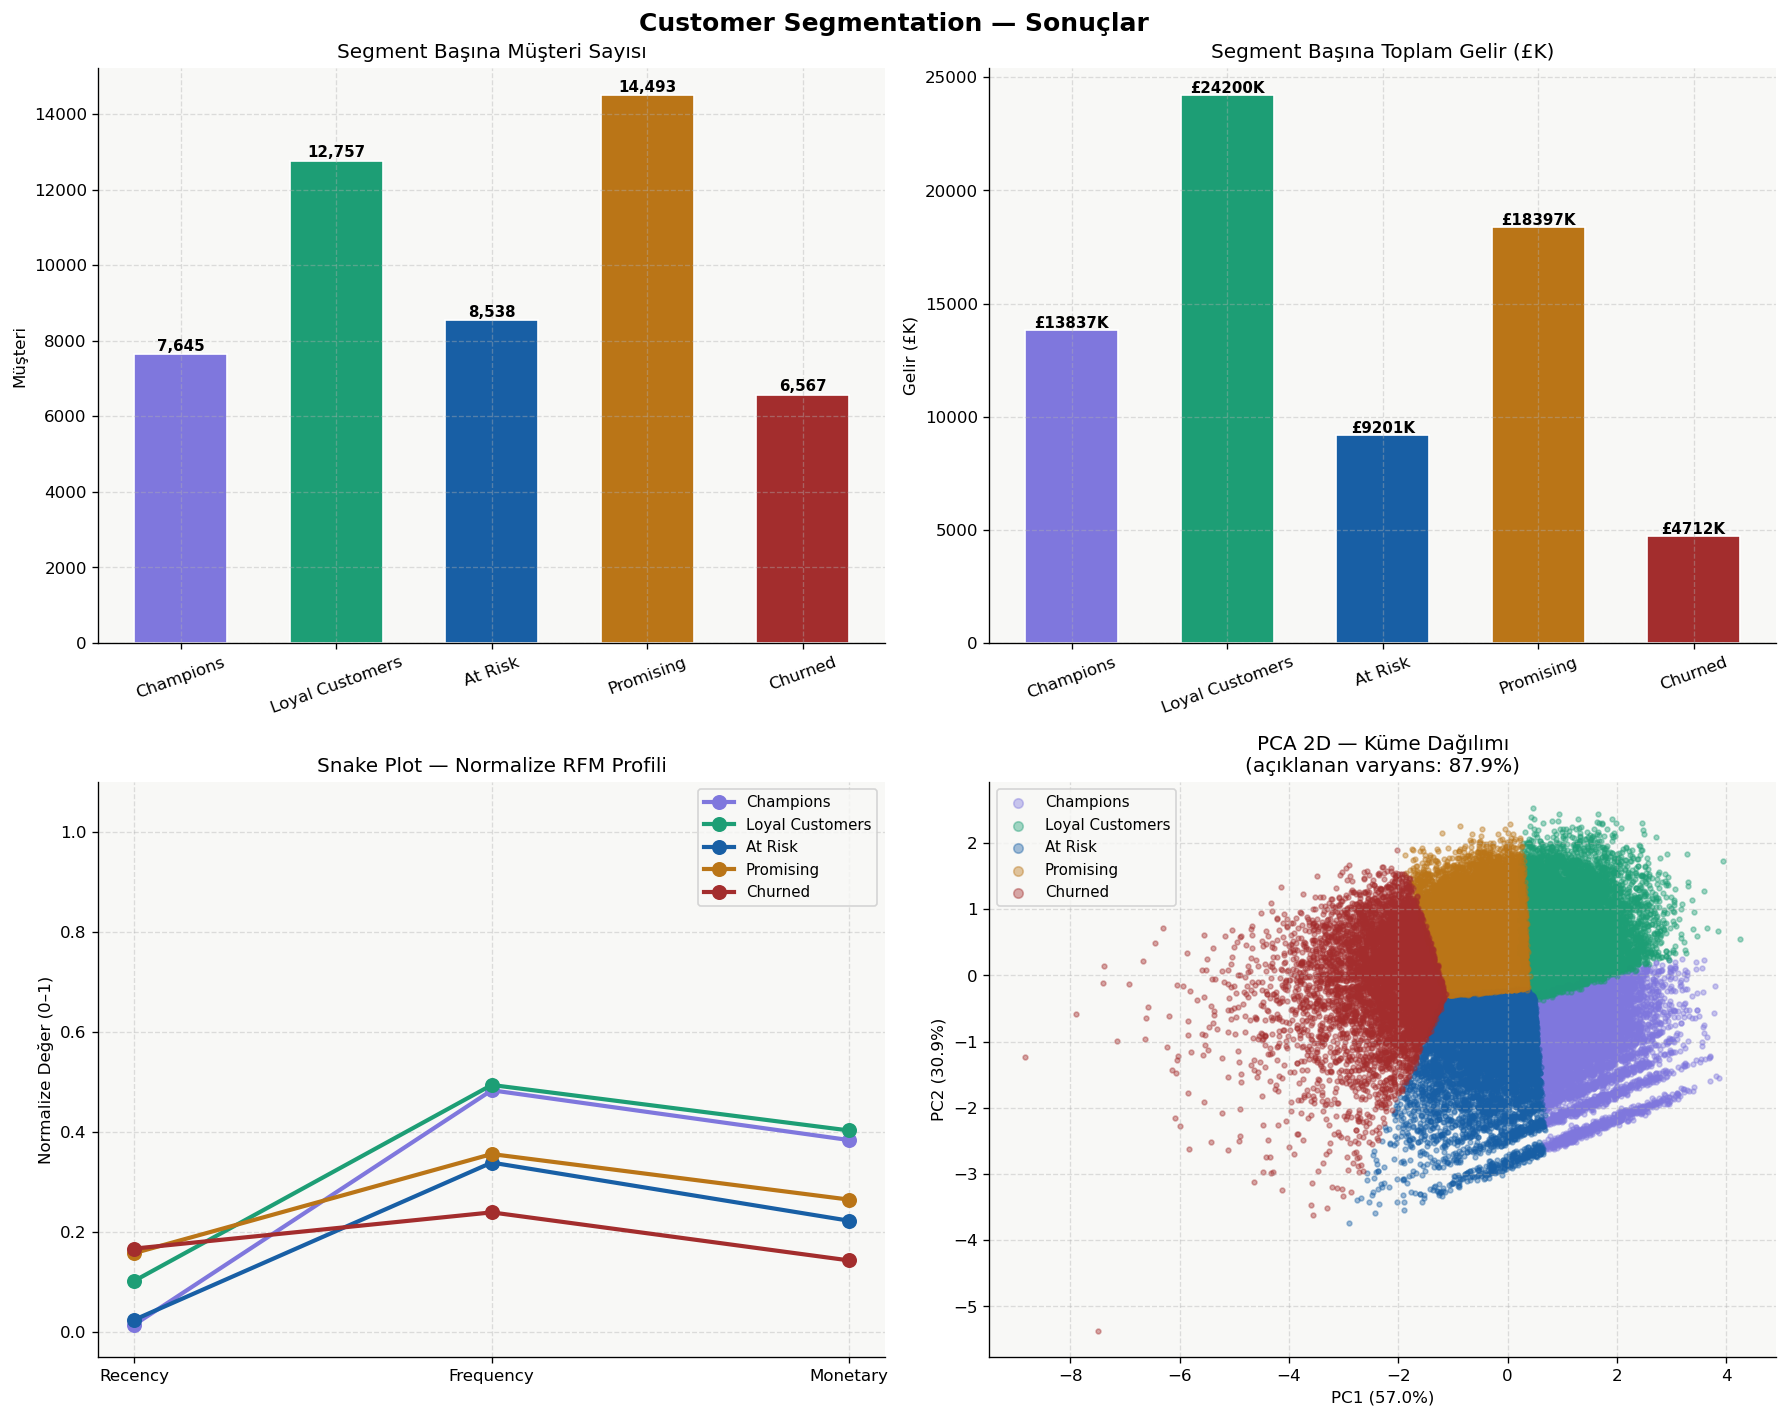

 Görselleştirme tamamlandı!


In [51]:
%matplotlib inline
from sklearn.decomposition import PCA

seg_order  = ['Champions', 'Loyal Customers', 'At Risk', 'Promising', 'Churned']
seg_colors = dict(zip(seg_order, PALETTE))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Customer Segmentation — Sonuçlar', fontsize=15, fontweight='bold')

ax = axes[0, 0]
counts = rfm['Segment'].value_counts().reindex(seg_order)
bars = ax.bar(seg_order, counts.values,
              color=[seg_colors[s] for s in seg_order],
              edgecolor='white', width=0.6)
ax.set_title('Segment Başına Müşteri Sayısı')
ax.set_ylabel('Müşteri')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    
ax = axes[0, 1]
revenue = rfm.groupby('Segment')['monetary'].sum().reindex(seg_order)
bars = ax.bar(seg_order, revenue.values / 1000,
              color=[seg_colors[s] for s in seg_order],
              edgecolor='white', width=0.6)
ax.set_title('Segment Başına Toplam Gelir (£K)')
ax.set_ylabel('Gelir (£K)')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'£{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')


ax = axes[1, 0]
rfm_norm = rfm.copy()
for col in ['recency', 'frequency', 'monetary']:
    rfm_norm[col] = (rfm[col] - rfm[col].min()) / (rfm[col].max() - rfm[col].min())

snake = rfm_norm.groupby('Segment')[['recency','frequency','monetary']].mean().reindex(seg_order)

for seg in seg_order:
    ax.plot(['Recency', 'Frequency', 'Monetary'], snake.loc[seg],
            marker='o', linewidth=2.5, markersize=8,
            color=seg_colors[seg], label=seg)

ax.set_title('Snake Plot — Normalize RFM Profili')
ax.set_ylabel('Normalize Değer (0–1)')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.1)


ax = axes[1, 1]
pca   = PCA(n_components=2, random_state=42)
pca2d = pca.fit_transform(rfm_scaled)

for seg in seg_order:
    mask = rfm['Segment'] == seg
    ax.scatter(pca2d[mask, 0], pca2d[mask, 1],
               c=seg_colors[seg], alpha=0.4, s=8, label=seg)

ax.set_title(f'PCA 2D — Küme Dağılımı\n'
             f'(açıklanan varyans: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()
print(" Görselleştirme tamamlandı!")

In [52]:
strategies = {
    'Champions': {
        'ikon'    : '🏆',
        'profil'  : 'En yakın, en sık, en çok harcayan müşteriler.',
        'aksiyon' : 'VIP program, erken ürün erişimi, referral ödülü.',
        'öncelik' : 'ELDE TUT',
    },
    'Loyal Customers': {
        'ikon'    : '💚',
        'profil'  : 'En yüksek toplam geliri üreten sadık müşteriler.',
        'aksiyon' : 'Sadakat puanı, özel indirim, cross-sell kampanyası.',
        'öncelik' : 'BÜYÜT',
    },
    'At Risk': {
        'ikon'    : '⚠️',
        'profil'  : 'Yakın zamanda gelmiş ama frequency/monetary düşük.',
        'aksiyon' : 'Kişiselleştirilmiş öneri, ilk büyük alışveriş indirimi.',
        'öncelik' : 'DÖNÜŞTÜR',
    },
    'Promising': {
        'ikon'    : '🌱',
        'profil'  : 'Uzaklaşmaya başlamış, orta seviye müşteriler.',
        'aksiyon' : '"Sizi özledik" e-postası, sınırlı süreli indirim kodu.',
        'öncelik' : 'GERİ KAZAN',
    },
    'Churned': {
        'ikon'    : '❌',
        'profil'  : 'En uzun süredir gelmeyen, en az harcayan grup.',
        'aksiyon' : 'Son şans %30 indirim, geri bildirim anketi.',
        'öncelik' : 'SON ŞANS',
    },
}


print("=" * 65)
print("  SEGMENT BAZLI PAZARLAMA STRATEJİLERİ")
print("=" * 65)

toplam_gelir = rfm['monetary'].sum()

for seg in ['Champions', 'Loyal Customers', 'At Risk', 'Promising', 'Churned']:
    s      = strategies[seg]
    profil = rfm[rfm['Segment'] == seg]
    gelir  = profil['monetary'].sum()
    oran   = gelir / toplam_gelir * 100

    print(f"\n{s['ikon']}  {seg}  [{s['öncelik']}]")
    print(f"   Müşteri  : {len(profil):,}  ({len(profil)/len(rfm)*100:.0f}%)")
    print(f"   Gelir    : £{gelir:,.0f}  (toplam gelirin %{oran:.0f}'i)")
    print(f"   Profil   : {s['profil']}")
    print(f"   Aksiyon  : {s['aksiyon']}")

print("\n" + "=" * 65)
print("\n  GELİR KONSANTRASYONU")
print("=" * 65)
for seg in ['Champions', 'Loyal Customers', 'At Risk', 'Promising', 'Churned']:
    gelir = rfm[rfm['Segment'] == seg]['monetary'].sum()
    oran  = gelir / toplam_gelir * 100
    bar   = '█' * int(oran / 2)
    print(f"  {seg:<20} {bar:<25} %{oran:.0f}")


output = rfm[['CustomerID', 'recency', 'frequency', 'monetary', 'Segment']]
output.to_csv('customer_segments.csv', index=False)

print(f"\n✅ CSV kaydedildi: customer_segments.csv")
print(f"   {len(output):,} müşteri, {output['Segment'].nunique()} segment")
print(f"\nİlk 10 satır:")
print(output.head(10).to_string(index=False))

  SEGMENT BAZLI PAZARLAMA STRATEJİLERİ

🏆  Champions  [ELDE TUT]
   Müşteri  : 7,645  (15%)
   Gelir    : £13,837,252  (toplam gelirin %20'i)
   Profil   : En yakın, en sık, en çok harcayan müşteriler.
   Aksiyon  : VIP program, erken ürün erişimi, referral ödülü.

💚  Loyal Customers  [BÜYÜT]
   Müşteri  : 12,757  (26%)
   Gelir    : £24,199,977  (toplam gelirin %34'i)
   Profil   : En yüksek toplam geliri üreten sadık müşteriler.
   Aksiyon  : Sadakat puanı, özel indirim, cross-sell kampanyası.

⚠️  At Risk  [DÖNÜŞTÜR]
   Müşteri  : 8,538  (17%)
   Gelir    : £9,201,334  (toplam gelirin %13'i)
   Profil   : Yakın zamanda gelmiş ama frequency/monetary düşük.
   Aksiyon  : Kişiselleştirilmiş öneri, ilk büyük alışveriş indirimi.

🌱  Promising  [GERİ KAZAN]
   Müşteri  : 14,493  (29%)
   Gelir    : £18,397,063  (toplam gelirin %26'i)
   Profil   : Uzaklaşmaya başlamış, orta seviye müşteriler.
   Aksiyon  : "Sizi özledik" e-postası, sınırlı süreli indirim kodu.

❌  Churned  [SON ŞANS]
   M